<h1>Опис роботи</h1>

Спершу почав гуглити цей Bow, знайшов пару цілу пачку статей на Medium, але це все було про класифікацію тексту (зберіг собі, щоб потім почитати).

Почав грузити датасети, залишив це діло, повернувся в мене комп з чорним екраном "No bootable Device" - думаю, ну от як завжди ще з цим розбиратись (благо люди в інтернетах діляться рішеннями).

Нового дня розпочав роботу над лабораторною доволі важко, потім знайшов запис практики, більш зрозуміло стало, що робити. Засейвив зображення, почав розбиратись.

MemoryError: Unable to allocate 21.0 GiB for an array with shape (44113452, 128) and data type float32 - почав пробувати розгортати на джупітерському сервері (якась лажа з картинками). 
Зрозумів, що VScode куди зручніший. Переглянув ще раз запис практики, спробував MiniBatchKMeans та Kmeans. Переписав код, підправив, зробив препроцесинг для кожного набору.

Як завжди, якась дурня "ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject" (ніяк не вдається зробити імпорт).

Шаманив, гуглив. Довелось відкатити версу numpy, і воно закомпілилось.
Нарешті, за два тижні вдалось завершити цю роботу.

<h4>Fetching & saving Data<h4>

In [1]:
from __future__ import print_function

import sys
import os, sys, tarfile, errno
import numpy as np
import matplotlib.pyplot as plt
    
if sys.version_info >= (3, 0, 0):
    import urllib.request as urllib # ugly but works
else:
    import urllib

try:
    from imageio import imsave
except:
    from scipy.misc import imsave

print(sys.version_info) 

# image shape
HEIGHT = 96
WIDTH = 96
DEPTH = 3

# size of a single image in bytes
SIZE = HEIGHT * WIDTH * DEPTH

# path to the directory with the data
DATA_DIR = './data'

# url of the binary data
DATA_URL = 'http://ai.stanford.edu/~acoates/stl10/stl10_binary.tar.gz'

# path to the binary train file with image data
DATA_PATH = './data/stl10_binary/train_X.bin'

# path to the binary train file with labels
LABEL_PATH = './data/stl10_binary/train_y.bin'

def read_labels(path_to_labels):
    """
    :param path_to_labels: path to the binary file containing labels from the STL-10 dataset
    :return: an array containing the labels
    """
    with open(path_to_labels, 'rb') as f:
        labels = np.fromfile(f, dtype=np.uint8)
        return labels


def read_all_images(path_to_data):
    """
    :param path_to_data: the file containing the binary images from the STL-10 dataset
    :return: an array containing all the images
    """

    with open(path_to_data, 'rb') as f:
        # read whole file in uint8 chunks
        everything = np.fromfile(f, dtype=np.uint8)

        # We force the data into 3x96x96 chunks, since the
        # images are stored in "column-major order", meaning
        # that "the first 96*96 values are the red channel,
        # the next 96*96 are green, and the last are blue."
        # The -1 is since the size of the pictures depends
        # on the input file, and this way numpy determines
        # the size on its own.

        images = np.reshape(everything, (-1, 3, 96, 96))

        # Now transpose the images into a standard image format
        # readable by, for example, matplotlib.imshow
        # You might want to comment this line or reverse the shuffle
        # if you will use a learning algorithm like CNN, since they like
        # their channels separated.
        images = np.transpose(images, (0, 3, 2, 1))
        return images


def read_single_image(image_file):
    """
    CAREFUL! - this method uses a file as input instead of the path - so the
    position of the reader will be remembered outside of context of this method.
    :param image_file: the open file containing the images
    :return: a single image
    """
    # read a single image, count determines the number of uint8's to read
    image = np.fromfile(image_file, dtype=np.uint8, count=SIZE)
    # force into image matrix
    image = np.reshape(image, (3, 96, 96))
    # transpose to standard format
    # You might want to comment this line or reverse the shuffle
    # if you will use a learning algorithm like CNN, since they like
    # their channels separated.
    image = np.transpose(image, (2, 1, 0))
    return image


def plot_image(image):
    """
    :param image: the image to be plotted in a 3-D matrix format
    :return: None
    """
    plt.imshow(image)
    plt.show()

def save_image(image, name):
    imsave("%s.png" % name, image, format="png")

def download_and_extract():
    """
    Download and extract the STL-10 dataset
    :return: None
    """
    dest_directory = DATA_DIR
    if not os.path.exists(dest_directory):
        os.makedirs(dest_directory)
    filename = DATA_URL.split('/')[-1]
    filepath = os.path.join(dest_directory, filename)
    if not os.path.exists(filepath):
        def _progress(count, block_size, total_size):
            sys.stdout.write('\rDownloading %s %.2f%%' % (filename,
                float(count * block_size) / float(total_size) * 100.0))
            sys.stdout.flush()
        filepath, _ = urllib.urlretrieve(DATA_URL, filepath, reporthook=_progress)
        print('Downloaded', filename)
        tarfile.open(filepath, 'r:gz').extractall(dest_directory)

def save_images(images, labels):
    print("Saving images to disk")
    i = 0
    for image in images:
        label = labels[i]
        directory = './img/' + str(label) + '/'
        try:
            os.makedirs(directory, exist_ok=True)
        except OSError as exc:
            if exc.errno == errno.EEXIST:
                pass
        filename = directory + str(i)
        print(filename)
        save_image(image, filename)
        i = i+1
    
# if __name__ == "__main__":
#     # download data if needed
#     download_and_extract()

#     # test to check if the image is read correctly
#     with open(DATA_PATH) as f:
#         image = read_single_image(f)
#         plot_image(image)

#     # test to check if the whole dataset is read correctly
#     images = read_all_images(DATA_PATH)
#     print(images.shape)

#     labels = read_labels(LABEL_PATH)
#     print(labels.shape)

#     # save images to disk
#     save_images(images, labels)


sys.version_info(major=3, minor=12, micro=0, releaselevel='final', serial=0)


<h4>Getting Data<h4>

In [2]:
from PIL import Image
import cv2

image = read_single_image(open(DATA_PATH))
# plot_image(image)

pil_image = Image.fromarray(image)

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)


In [3]:
DATA_TRAIN_PATH = './data/stl10_binary/train_X.bin'
DATA_TEST_PATH = './data/stl10_binary/test_X.bin'

LABEL_TRAIN_PATH = './data/stl10_binary/train_y.bin'
LABEL_TEST_PATH = './data/stl10_binary/test_y.bin'

In [4]:
X_train = read_all_images(DATA_TRAIN_PATH)
X_train.shape

(5000, 96, 96, 3)

In [5]:
y_train = read_labels(LABEL_TRAIN_PATH)
y_train.shape

(5000,)

In [6]:
X_test = read_all_images(DATA_TEST_PATH)
X_test.shape

(8000, 96, 96, 3)

In [7]:
y_test = read_labels(LABEL_TEST_PATH)
y_test.shape

(8000,)

<h4>Descriptors<h4>

In [8]:
import cv2

sift = cv2.SIFT_create()

In [9]:
def get_descriptors(X):
    descriptors = []
    for img in X:
        _, temp_descs = sift.detectAndCompute(img, None)
        if temp_descs is not None:
            for d in temp_descs:
                descriptors.append(d)
    return descriptors

In [10]:
X_train_descr = get_descriptors(X_train)
X_test_descr = get_descriptors(X_test)

len(X_train_descr)

433690

In [11]:
len(X_test_descr)

694306

<h4>Clustering<h4>

In [12]:
from sklearn.cluster import KMeans, MiniBatchKMeans

In [13]:
k=1000

In [14]:
def clustering(descriptors):
    kmeans = MiniBatchKMeans(n_clusters=k, batch_size=15000, verbose=1).fit(descriptors)
    return kmeans

In [15]:
kmeans_train = clustering(X_train_descr)

Init 1/1 with method k-means++
Inertia for init 1/1: 4510773018.0
Minibatch step 1/2891: mean batch inertia: 100296.65133333333
Minibatch step 2/2891: mean batch inertia: 76072.26393221894, ewa inertia: 76072.26393221894
Minibatch step 3/2891: mean batch inertia: 74387.53272497845, ewa inertia: 75955.72488433181
Minibatch step 4/2891: mean batch inertia: 73421.16603681506, ewa inertia: 75780.40013600753
Minibatch step 5/2891: mean batch inertia: 72567.33498262221, ewa inertia: 75558.14061344064
Minibatch step 6/2891: mean batch inertia: 72697.97586492234, ewa inertia: 75360.29250855594
Minibatch step 7/2891: mean batch inertia: 72147.65332835358, ewa inertia: 75138.06245211928
Minibatch step 8/2891: mean batch inertia: 72465.42149296182, ewa inertia: 74953.1860567716
Minibatch step 9/2891: mean batch inertia: 72317.29570542945, ewa inertia: 74770.8518360009
Minibatch step 10/2891: mean batch inertia: 72044.20685924722, ewa inertia: 74582.23978432675
Minibatch step 11/2891: mean batch i

In [16]:
kmeans_test = clustering(X_test_descr)

Init 1/1 with method k-means++
Inertia for init 1/1: 4496634477.0
Minibatch step 1/4628: mean batch inertia: 100319.95346666667
[MiniBatchKMeans] Reassigning 2 cluster centers.
Minibatch step 2/4628: mean batch inertia: 76248.24036124318, ewa inertia: 76248.24036124318
[MiniBatchKMeans] Reassigning 4 cluster centers.
Minibatch step 3/4628: mean batch inertia: 74317.80217472508, ewa inertia: 76164.8289227937
Minibatch step 4/4628: mean batch inertia: 73783.55104534327, ewa inertia: 76061.9373541886
[MiniBatchKMeans] Reassigning 2 cluster centers.
Minibatch step 5/4628: mean batch inertia: 73506.56387830057, ewa inertia: 75951.52336689389
Minibatch step 6/4628: mean batch inertia: 72971.02373578015, ewa inertia: 75822.74029408401
[MiniBatchKMeans] Reassigning 2 cluster centers.
Minibatch step 7/4628: mean batch inertia: 72655.61494903285, ewa inertia: 75685.89339443942
Minibatch step 8/4628: mean batch inertia: 72523.04310958092, ewa inertia: 75549.23121395479
Minibatch step 9/4628: mean

<h4>Normalized histograms<h4>

In [17]:
def get_normalized_histogram(X, kmeans):
    histogram_list = []
    
    for i, img in enumerate(X):
        print(f'{i} out of {len(X)} images processed')
        keypoints, descriptors = sift.detectAndCompute(img, None)

        histogram = np.zeros(k)
        n_keypoints = np.size(keypoints)

        if descriptors is not None:
            for d in descriptors:
                idx = kmeans.predict([d])

                histogram[idx] += 1 / n_keypoints
        
        histogram_list.append(histogram)
        
    return histogram_list

In [18]:
kmeans_train.verbose = False
histograms_train = get_normalized_histogram(X=X_train, kmeans=kmeans_train)

0 out of 5000 images processed
1 out of 5000 images processed
2 out of 5000 images processed
3 out of 5000 images processed
4 out of 5000 images processed
5 out of 5000 images processed
6 out of 5000 images processed
7 out of 5000 images processed
8 out of 5000 images processed
9 out of 5000 images processed
10 out of 5000 images processed
11 out of 5000 images processed
12 out of 5000 images processed
13 out of 5000 images processed
14 out of 5000 images processed
15 out of 5000 images processed
16 out of 5000 images processed
17 out of 5000 images processed
18 out of 5000 images processed
19 out of 5000 images processed
20 out of 5000 images processed
21 out of 5000 images processed
22 out of 5000 images processed
23 out of 5000 images processed
24 out of 5000 images processed
25 out of 5000 images processed
26 out of 5000 images processed
27 out of 5000 images processed
28 out of 5000 images processed
29 out of 5000 images processed
30 out of 5000 images processed
31 out of 5000 ima

In [19]:
kmeans_test.verbose = False
histograms_test = get_normalized_histogram(X=X_test, kmeans=kmeans_test)

0 out of 8000 images processed
1 out of 8000 images processed
2 out of 8000 images processed
3 out of 8000 images processed
4 out of 8000 images processed
5 out of 8000 images processed
6 out of 8000 images processed
7 out of 8000 images processed
8 out of 8000 images processed
9 out of 8000 images processed
10 out of 8000 images processed
11 out of 8000 images processed
12 out of 8000 images processed
13 out of 8000 images processed
14 out of 8000 images processed
15 out of 8000 images processed
16 out of 8000 images processed
17 out of 8000 images processed
18 out of 8000 images processed
19 out of 8000 images processed
20 out of 8000 images processed
21 out of 8000 images processed
22 out of 8000 images processed
23 out of 8000 images processed
24 out of 8000 images processed
25 out of 8000 images processed
26 out of 8000 images processed
27 out of 8000 images processed
28 out of 8000 images processed
29 out of 8000 images processed
30 out of 8000 images processed
31 out of 8000 ima

In [20]:
len(histograms_test)

8000

<h4>SVM classifier<h4>

In [21]:
from sklearn.svm import LinearSVC

In [22]:
X_train_histograms = np.array(histograms_train)

In [23]:
X_train_histograms.shape

(5000, 1000)

In [24]:
y_train.shape

(5000,)

In [25]:
svm = LinearSVC(C=10, tol=0.001)

In [26]:
svm.fit(X_train_histograms, y_train)

d:\Program Files\Python312\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


LinearSVC(C=10, tol=0.001)

In [27]:
y_true = y_train

In [28]:
y_pred_train = svm.predict(X_train_histograms)

In [29]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, balanced_accuracy_score, f1_score

In [60]:
print('Balanced accuracy train: {:.4f}'.format(balanced_accuracy_score(y_true, y_pred_train)))

Balanced accuracy train: 0.6796


In [61]:
print('F1-score train: {:.4f}'.format(f1_score(y_true, y_pred_train, average='macro')))

F1-score train: 0.6762


In [36]:
cm = confusion_matrix(y_true, y_pred_train)
cm

array([[397,   4,  30,   2,  13,   2,   4,   3,  26,  19],
       [ 37, 239,  27,  44,  40,  32,  23,  33,  11,  14],
       [  7,   3, 410,   5,   4,   1,   8,   4,  18,  40],
       [  5,  12,   8, 338,  42,  32,  14,  28,  11,  10],
       [ 20,  11,  11,  36, 344,  21,  22,  17,  10,   8],
       [ 12,  17,  12,  40,  27, 317,  24,  35,   9,   7],
       [ 18,  15,  16,  19,  36,  37, 291,  30,  14,  24],
       [ 10,  21,  20,  33,  33,  27,  23, 308,  14,  11],
       [ 20,   9,  25,   9,  12,   6,  10,   4, 376,  29],
       [  6,   3,  36,   7,   5,  11,   9,   9,  36, 378]], dtype=int64)

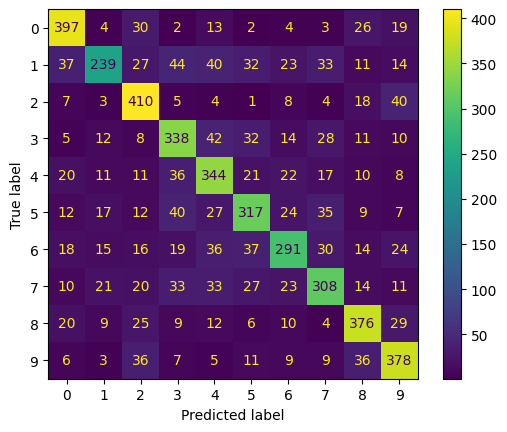

In [47]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

<h4>Evaluation on test set<h4>

In [63]:
X_test_histograms = np.array(histograms_test)

In [80]:
len(X_test_descr)

694306

In [65]:
X_test_histograms = np.array(histograms_test)

In [66]:
X_test_histograms.shape

(8000, 1000)

In [67]:
y_test.shape

(8000,)

In [68]:
svm.fit(X_test_histograms, y_test)

d:\Program Files\Python312\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


LinearSVC(C=10, tol=0.001)

In [69]:
y_true = y_test

In [70]:
y_pred_test = svm.predict(X_test_histograms)

In [72]:
y_pred_test = svm.predict(X_test_histograms)

In [73]:
print('Balanced accuracy test (k=1000): {:.4f}'.format(balanced_accuracy_score(y_true, y_pred_test)))

Balanced accuracy test: 0.6011


In [74]:
print('F1-score test (k=1000): {:.4f}'.format(f1_score(y_true, y_pred_test, average='macro')))

F1-score test: 0.5968


In [76]:
cm = confusion_matrix(y_true, y_pred_test)
cm

array([[585,  12,  35,   6,  16,  11,  15,   8,  82,  30],
       [ 66, 323,  23,  91,  78,  47,  51,  76,  26,  19],
       [ 20,   6, 577,  11,   9,  13,  24,   9,  37,  94],
       [ 12,  26,  34, 439,  60,  61,  30,  79,  29,  30],
       [ 32,  23,  15,  55, 511,  33,  48,  41,  21,  21],
       [ 26,  44,  26,  63,  60, 410,  52,  74,  22,  23],
       [ 24,  44,  35,  37,  73,  67, 404,  52,  22,  42],
       [ 11,  42,  33,  76,  66,  57,  53, 423,  10,  29],
       [ 58,  11,  37,  17,  18,  12,   9,   9, 582,  47],
       [ 24,  10,  82,  14,  13,   4,  21,  12,  65, 555]], dtype=int64)

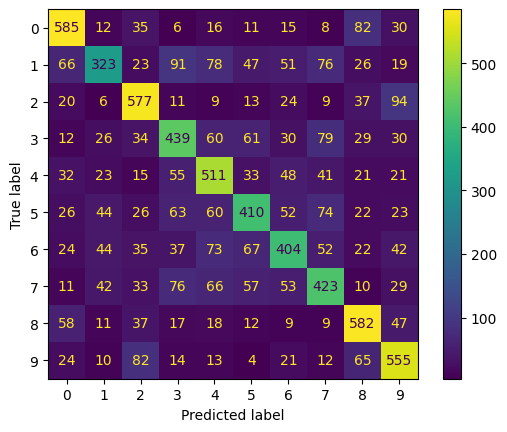

In [77]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

<h1>Висновки</h1>

Тепер до висновків. Я вкотре розумію, що мені важко полюбити Python...

А тепер по роботі. У роботі реалізований класифікатор BoW використовуючи набір даних STL-10.

Спершу визначались ознаки за допомогою SIFT-алгоритму, далі відбувалась кластеризація і відповідно класифікація за допомогою SVM. 

Якщо проходитись по кожному окремо, то SIFT дозволив визначити дескриптори, які в свою чергу рятують ситуації коли наприклад однакові 
об'єкти при різних масштабах чи орієнтації. У частині а з кластеризацією k відбулось групування і зменшення кількості схожих ознак. 

Класифікація за допомогою SVM був основним, оскільки це сотворило зв'язок між візуалом та обраними ознаками на зображеннях.

Алгоритм було протестовано та пораховано метрики. Можна сказати, що його точність залежить від кількості виявлених ознак та k 
(кластерів, в алгоритмі кластеризації з k).


<h1>What are the main differences with the original BoW approach?</h1>
У статті автори досліджують кілька варіацій підходу Bag-of-Words (BoW), зосереджуючись на різних методах класифікації. Однією з головних відмінностей є використання алгоритму boosting замість базаового SVM. Boosting поєднує кілька слабких класифікаторів, які окремо мають помірну точність, але разом вони покращують кореляцію між прогнозованими та фактичними ознаками.

Також є згадка про так звані слабкі геометричні класифікатори. Цей метод враховує геометрію, підраховуючи кількість ключових точок, що належать до певного кластера k і мають певну орієнтацію.

Результати, представлені в статті, показують, що різні комбінації класифікаторів і геометрії впливають на точність класифікації. Зокрема, вони наводять наступні  відсотки точності:

- Boosting без геометрії: 66.4%
- Лінійний SVM: 74.1%
- Boosting зі слабкою геометрією: 69.8%
- SVM зі слабкою геометрією: 78.7%

Ці результати свідчать про те, що включення геометрії, особливо в поєднанні з SVM, може суттєво покращити точність класифікації.